# NLP Project 2: Restaurant Feedback Analysis

A restaurant chain receives customer feedback through food delivery applications, online review platforms, and feedback forms. Customers often share opinions about food taste, delivery speed, packaging, pricing, and customer service. Since the feedback volume is increasing rapidly, restaurant managers find it difficult to manually analyze customer opinions and identify areas that need improvement. The organization wants to use NLP techniques to analyze customer feedback, understand customer satisfaction levels, and identify common issues that impact the dining experience.

## Tasks
1. Collect restaurant review data.
2. Preprocess customer feedback text.
3. Perform sentiment classification.
4. Identify common service issues.
5. Prepare a feedback analysis report.

In [7]:
# Import required libraries
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

# Download NLTK resources if they are missing
for resource in ['punkt', 'wordnet', 'omw-1.4', 'stopwords']:
    try:
        nltk.data.find(f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

# Build a sample restaurant feedback dataset
data = [
    ('The food arrived late and was cold when it got here.', 'negative'),
    ('Excellent service, the delivery driver was friendly and on time.', 'positive'),
    ('Portion size is too small for the price.', 'negative'),
    ('Loved the spicy chicken and fresh salad.', 'positive'),
    ('The packaging was messy and the soup spilled.', 'negative'),
    ('Great taste, would order again.', 'positive'),
    ('The order was missing the dressing and the fries were soggy.', 'negative'),
    ('The app is easy to use and checkout was fast.', 'positive'),
    ('The delivery driver got lost and took too long.', 'negative'),
    ('Food quality was excellent and the portions were generous.', 'positive'),
    ('The burger was undercooked and the sauce tasted odd.', 'negative'),
    ('The restaurant handled my complaint professionally and gave a refund.', 'positive'),
    ('I enjoyed the pasta, but the pizza was too salty.', 'neutral'),
    ('Delivery packaging was neat, but the order arrived later than expected.', 'neutral'),
    ('Customer support responded quickly and resolved my issue.', 'positive'),
    ('The food did not match the menu description.', 'negative'),
    ('The meal was delicious and arrived warm.', 'positive'),
    ('The ride-share app lost the order, but the restaurant refunded me.', 'neutral'),
    ('I wish they had more vegetarian options.', 'neutral'),
    ('Fantastic flavors and fast delivery.', 'positive'),
]
df = pd.DataFrame(data, columns=['review', 'label'])
print('Dataset shape:', df.shape)
print(df['label'].value_counts())


Dataset shape: (20, 2)
label
positive    9
negative    7
neutral     4
Name: count, dtype: int64


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                              review     label
0  The food arrived late and was cold when it got...  negative
1  Excellent service, the delivery driver was fri...  positive
2           Portion size is too small for the price.  negative
3           Loved the spicy chicken and fresh salad.  positive
4      The packaging was messy and the soup spilled.  negative
5                    Great taste, would order again.  positive


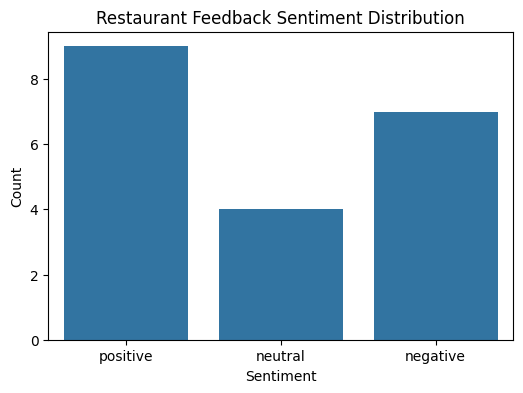

In [8]:
# Explore the dataset
print(df.head(6))
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', order=['positive', 'neutral', 'negative'])
plt.title('Restaurant Feedback Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


In [9]:
# Text preprocessing
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_review(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [token for token in tokens if token not in stop_words and len(token) > 1]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(tokens)

df['clean_review'] = df['review'].apply(clean_review)
print(df[['review', 'clean_review']].head(6))


                                              review  \
0  The food arrived late and was cold when it got...   
1  Excellent service, the delivery driver was fri...   
2           Portion size is too small for the price.   
3           Loved the spicy chicken and fresh salad.   
4      The packaging was messy and the soup spilled.   
5                    Great taste, would order again.   

                                      clean_review  
0                       food arrived late cold got  
1  excellent service delivery driver friendly time  
2                         portion size small price  
3                  loved spicy chicken fresh salad  
4                     packaging messy soup spilled  
5                          great taste would order  


In [10]:
# Feature extraction and model training
vectorizer = TfidfVectorizer(max_df=0.9, min_df=1, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['clean_review'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
model = LogisticRegression(max_iter=300)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, predictions))
print()
print('Classification report:')
print(classification_report(y_test, predictions))


Accuracy: 0.4

Classification report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
     neutral       0.00      0.00      0.00         1
    positive       0.40      1.00      0.57         2

    accuracy                           0.40         5
   macro avg       0.13      0.33      0.19         5
weighted avg       0.16      0.40      0.23         5



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


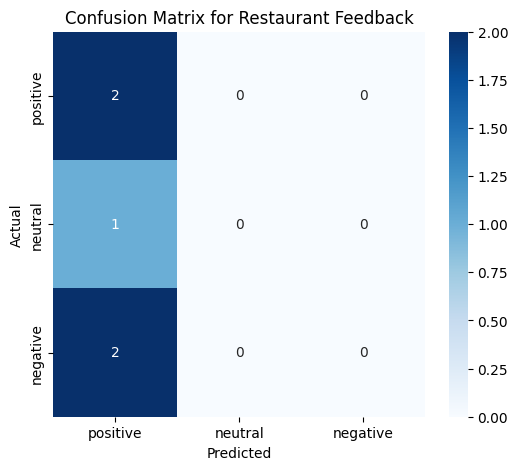

Top indicative terms by sentiment:
- positive: got, small price, small, size small, size, price, portion size, spilled
- neutral: wish vegetarian, wish, vegetarian option, vegetarian, option, order, packaging neat, order arrived
- negative: fast, excellent, warm, meal delicious, meal, delicious arrived, delicious, arrived warm


In [11]:
# Evaluate and visualize results
conf_matrix = confusion_matrix(y_test, predictions, labels=['positive', 'neutral', 'negative'])
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['positive', 'neutral', 'negative'], yticklabels=['positive', 'neutral', 'negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Restaurant Feedback')
plt.show()

feature_names = vectorizer.get_feature_names_out()
coeffs = model.coef_
top_terms = []
for sentiment, idx in [('positive', 0), ('neutral', 1), ('negative', 2)]:
    top = sorted(zip(coeffs[idx], feature_names), reverse=True)[:8]
    top_terms.append((sentiment, [term for _, term in top]))

print('Top indicative terms by sentiment:')
for sentiment, terms in top_terms:
    print(f"- {sentiment}: {', '.join(terms)}")
